# Standard Bayesian Optimization with FCVOpt

While FCVOpt is designed for hyperparameter optimization via fractional cross-validation, the underlying `BayesOpt` class can be used for **standard Bayesian optimization** of any black-box function—no cross-validation required.

This notebook demonstrates `BayesOpt` on the classic **Branin function**, a standard benchmark for global optimization. Unlike the CV setting, the observed objective values here are direct evaluations of the true loss function (not fold-level proxies), so we can meaningfully plot the **best observed value so far** and track how the optimizer converges to the global minimum.

## The Branin Function

The 2-dimensional Branin function is defined as:

$$f(x_1, x_2) = a\left(x_2 - bx_1^2 + cx_1 - r\right)^2 + s(1-t)\cos(x_1) + s$$

with standard constants $a=1$, $b=5.1/(4\pi^2)$, $c=5/\pi$, $r=6$, $s=10$, $t=1/(8\pi)$, over the domain $x_1 \in [-5, 10]$, $x_2 \in [0, 15]$.

It has **three global minima**, all attaining $f^* \approx 0.3979$:
- $(-\pi,\; 12.275)$
- $(\pi,\; 2.275)$
- $(9.425,\; 2.475)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fcvopt.optimizers import BayesOpt
from fcvopt.configspace import ConfigurationSpace
from ConfigSpace import Float

## Define the Objective Function

`BayesOpt` expects an objective that takes a **dict of hyperparameter values** and returns a scalar. We wrap the Branin formula accordingly.

In [2]:
def branin(params: dict) -> float:
    """Branin function. Global minimum f* ≈ 0.3979."""
    x1, x2 = params['x1'], params['x2']
    a, b, c = 1.0, 5.1 / (4 * np.pi**2), 5.0 / np.pi
    r, s, t = 6.0, 10.0, 1.0 / (8 * np.pi)
    return float(a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s)

BRANIN_OPTIMUM = 0.397887
print(f"Branin global minimum: {BRANIN_OPTIMUM:.6f}")
print(f"Value at (pi, 2.275): {branin({'x1': np.pi, 'x2': 2.275}):.6f}")

Branin global minimum: 0.397887
Value at (pi, 2.275): 0.397887


## Define the Search Space

We use FCVOpt's `ConfigurationSpace` to declare the two continuous inputs with their standard Branin bounds.

In [3]:
config = ConfigurationSpace(seed=42)
config.add([
    Float('x1', bounds=(-5.0, 10.0)),
    Float('x2', bounds=(0.0, 15.0)),
])
print(config)

Configuration space object:
  Hyperparameters:
    x1, Type: UniformFloat, Range: [-5.0, 10.0], Default: 2.5
    x2, Type: UniformFloat, Range: [0.0, 15.0], Default: 7.5



## Run Standard Bayesian Optimization

`BayesOpt` follows the same API as `FCVOpt` but fits a standard (non-hierarchical) GP directly on the observed `(x, y)` pairs.

Key arguments:

| Argument | Description |
|---|---|
| `obj` | Black-box function: `dict → float` |
| `config` | Hyperparameter / input search space |
| `acq_function` | `'EI'` (Expected Improvement), `'LCB'`, or `'KG'` |
| `tracking_dir` | Local directory for MLflow experiment logs |
| `experiment` | MLflow experiment name |
| `seed` | Random seed for reproducibility |

We run **30 total evaluations**: 5 random initializations followed by 25 acquisition-guided steps.

In [4]:
optimizer = BayesOpt(
    obj=branin,
    config=config,
    acq_function='EI',
    tracking_dir='./opt_runs/',
    experiment='branin_standard_bo',
    seed=123,
)

best_conf = optimizer.optimize(n_trials=30, n_init=5)
optimizer.end_run()


Number of candidates evaluated.....: 30
Observed obj at incumbent..........: 0.398315
Estimated obj at incumbent.........: 0.423703

 Best Configuration at termination:
 Configuration(values={
  'x1': 9.4327962845392,
  'x2': 2.4926768337029,
})


In [5]:
print(f"Best configuration found:")
print(f"  x1 = {dict(best_conf)['x1']:.4f}")
print(f"  x2 = {dict(best_conf)['x2']:.4f}")
print(f"  f(x1, x2) = {branin(dict(best_conf)):.6f}")
print(f"  Known global minimum = {BRANIN_OPTIMUM:.6f}")
print(f"  Optimality gap = {branin(dict(best_conf)) - BRANIN_OPTIMUM:.6f}")

Best configuration found:
  x1 = 9.4328
  x2 = 2.4927
  f(x1, x2) = 0.398315
  Known global minimum = 0.397887
  Optimality gap = 0.000428


## Optimization Progress

Internally, `BayesOpt` selects the incumbent at each step as the training point with the **lowest GP posterior mean**—not necessarily the lowest observed value. This means `f_inc_obs` (the observed value at the GP-based incumbent) can fluctuate non-monotonically as the GP model is updated.

Because we are optimizing a direct, noise-free function rather than a CV proxy, a cleaner quantity to track is the **best observed value so far**: the running minimum over all evaluations. This is guaranteed to decrease monotonically and directly reflects how much the optimizer has improved the objective.

The plot below shows this quantity alongside all individual observations, with the known global minimum as a dashed reference line.

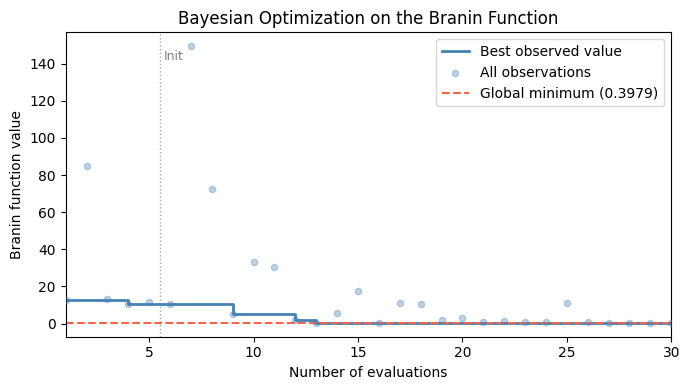

In [6]:
observed_y = optimizer.observed_values
best_so_far = np.minimum.accumulate(observed_y)
n_evals = np.arange(1, len(observed_y) + 1)

fig, ax = plt.subplots(figsize=(7, 4))

ax.step(n_evals, best_so_far, where='post', color='steelblue', lw=2, label='Best observed value')
ax.scatter(n_evals, observed_y, color='steelblue', alpha=0.35, s=20, zorder=3, label='All observations')
ax.axhline(BRANIN_OPTIMUM, color='tomato', lw=1.5, ls='--', label=f'Global minimum ({BRANIN_OPTIMUM:.4f})')
ax.axvline(5.5, color='gray', lw=1, ls=':', alpha=0.7)
ax.text(5.7, observed_y.max() * 0.95, 'Init', color='gray', fontsize=9)

ax.set_xlabel('Number of evaluations')
ax.set_ylabel('Branin function value')
ax.set_title('Bayesian Optimization on the Branin Function')
ax.legend(loc='upper right')
ax.set_xlim(1, len(observed_y))
plt.tight_layout()
plt.show()